In [1]:
from pathlib import Path
from shutil import rmtree
from collections import Counter
from math import ceil
from json import dump
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.pipeline import Pipeline as imbPipeline
from sklearn.pipeline import Pipeline as sklPipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTENC
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import PrecisionRecallDisplay

RANDOM_STATE = 12345

# Data

In [2]:
train_data = Path("../datasense/dataset/datasense_full_train_1sec.parquet")
train_data = pd.read_parquet(train_data)
y_balance = train_data["label_extended"]

# Results directory
results_dir = Path("results/decision_tree/")
results_dir.mkdir(exist_ok=True, parents=True)

# Cache directory for pipeline memoization
cache_dir = Path("results/decision_tree_cache/")
if cache_dir.is_dir():
    rmtree(cache_dir, ignore_errors=True)
cache_dir.mkdir(exist_ok=True)

# Experiments

## Data balancing

In [3]:
def undersampling_strategy(y):
    ordered_counts = Counter(y).most_common()
    max_samples = 50
    return {
        cls: max_samples
        for cls, cnt in ordered_counts
        if cnt > max_samples
    }

def oversampling_strategy(y):
    full_counts = list(zip(*np.unique(y, return_counts=True)))
    device_count_per_attack = Counter((atk.split("/")[0] for atk, _ in full_counts))
    majority_count = sum(count for atk, count in full_counts if atk.startswith("benign/"))
    num_samples_per_attack = {
        atk: round(majority_count / dcount)
        for atk, dcount in device_count_per_attack.items()
    }
    return {
        atk: num_samples_per_attack[atk.split("/")[0]]
        for atk, count in full_counts
        if count < num_samples_per_attack[atk.split("/")[0]]
    }

In [4]:
balance_pipe = imbPipeline(
    steps=[
        (
            "drop",
            make_column_transformer(
                ("drop", [0, 1, 2, 3, 4, 69]),
                remainder="passthrough",
                verbose_feature_names_out=False,
            ),
        ),
        (
            "partial_under_sampling",
            RandomUnderSampler(
                sampling_strategy=undersampling_strategy,
                random_state=RANDOM_STATE,
                replacement=False,
            ),
        ),
        (
            "oversampling",
            SMOTENC(
                categorical_features=[-1],
                sampling_strategy=oversampling_strategy,
                random_state=RANDOM_STATE,
            ),
        ),
    ],
)

In [5]:
X_train, y_train = balance_pipe.fit_resample(train_data, y_balance)

del train_data, y_balance

print("Attack classes after balancing:")
print("\n".join(
    f"- {cls}: {cnt}" for cls, cnt in Counter(y_train).most_common()
))

y_train = y_train.str.split("/", expand=True).iloc[:, 0]

Attack classes after balancing:
- ddos_connect-flood/mqtt-broker: 1900
- ddos_mqtt-publish-flood/mqtt-broker: 1900
- ddos_slowloris-port-1883/mqtt-broker: 1900
- ddos_slowloris-port-554/wisenet-camera: 1900
- ddos_slowloris-port-8000/edge1: 1900
- dos_connect-flood/mqtt-broker: 1900
- dos_http-flood-port-1883/mqtt-broker: 1900
- dos_http-flood-port-443/wisenet-camera: 1900
- dos_http-flood-port-554/wisenet-camera: 1900
- dos_http-flood-port-9595/myq-camera: 1900
- dos_mqtt-publish-flood/mqtt-broker: 1900
- dos_slowloris-port-1883/mqtt-broker: 1900
- dos_slowloris-port-554/wisenet-camera: 1900
- dos_slowloris-port-8000/edge1: 1900
- dos_syn-flood-port-557/wisenet-camera: 1900
- web_backdoor-upload/edge1: 1900
- web_command-injection/edge1: 1900
- web_sql-injection-blind/edge1: 1900
- web_sql-injection/edge1: 1900
- web_xss/edge1: 1900
- dos_syn-flood-port-22/edge1: 950
- dos_syn-flood-port-22/mqtt-broker: 950
- dos_syn-flood-port-23/router: 950
- dos_syn-flood-port-23/switch: 950
- dos_

## Training pipe

In [6]:
train_pipe = sklPipeline(
    steps=[
        (
            "onehot",
            make_column_transformer(
                (OneHotEncoder(drop="first"), [-1]),
                remainder="passthrough",
                verbose_feature_names_out=False,
            ),
        ),
        ("model", DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ],
    memory=str(cache_dir),
    verbose=False,
)

## Grid seach cross-validations

In [7]:
param_grid = {
    # "model__criterion": ["gini", "entropy"],
    # "model__splitter": ["best", "random"],
    "model__max_depth": [8, 16],
    # "model__max_features": [None, "log2"],
}

In [8]:
grid = GridSearchCV(
    train_pipe,
    param_grid,
    scoring="f1_macro",
    n_jobs=3,
    refit=True,
    cv=10,
    verbose=0,
    return_train_score=True,
)

grid.fit(X_train, y_train)
trained_model = grid.best_estimator_
trained_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('onehot', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",'results/decision_tree_cache'
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the dif

# Evaluations

In [9]:
del X_train, y_train

test_data = Path("../datasense/dataset/datasense_full_test_1sec.parquet")
test_data = pd.read_parquet(test_data)

X_test = balance_pipe[:1].transform(test_data)
y_test = test_data["label4"]

del test_data

In [10]:
y_pred = trained_model.predict(X_test)
y_proba = trained_model.predict_proba(X_test)

## Classification report

In [11]:
results = classification_report(y_test, y_pred, zero_division=0, output_dict=True)

with (results_dir / "report.json").open("w") as f:
    dump(results, f, indent=4)

print(classification_report(y_test, y_pred, zero_division=0))

                                   precision    recall  f1-score   support

                           benign       0.96      0.01      0.01     34200
        bruteforce_dictionary-ssh       0.02      0.37      0.04       240
     bruteforce_dictionary-telnet       0.43      0.19      0.26       225
    ddos_ack-frag-flood-port-1883       0.99      0.85      0.92       232
      ddos_ack-frag-flood-port-80       1.00      0.80      0.89       168
               ddos_connect-flood       1.00      0.87      0.93        15
        ddos_http-flood-port-1883       0.61      0.79      0.68       225
          ddos_http-flood-port-80       0.92      0.35      0.51       167
                  ddos_icmp-flood       0.96      0.83      0.89       400
             ddos_icmp-frag-flood       0.98      0.83      0.90       395
          ddos_mqtt-publish-flood       0.93      0.87      0.90        15
    ddos_push-ack-flood-port-1883       1.00      0.87      0.93       231
      ddos_push-ack-floo

## Confusion matrix

In [12]:
cm = confusion_matrix(y_test, y_pred, normalize="true")

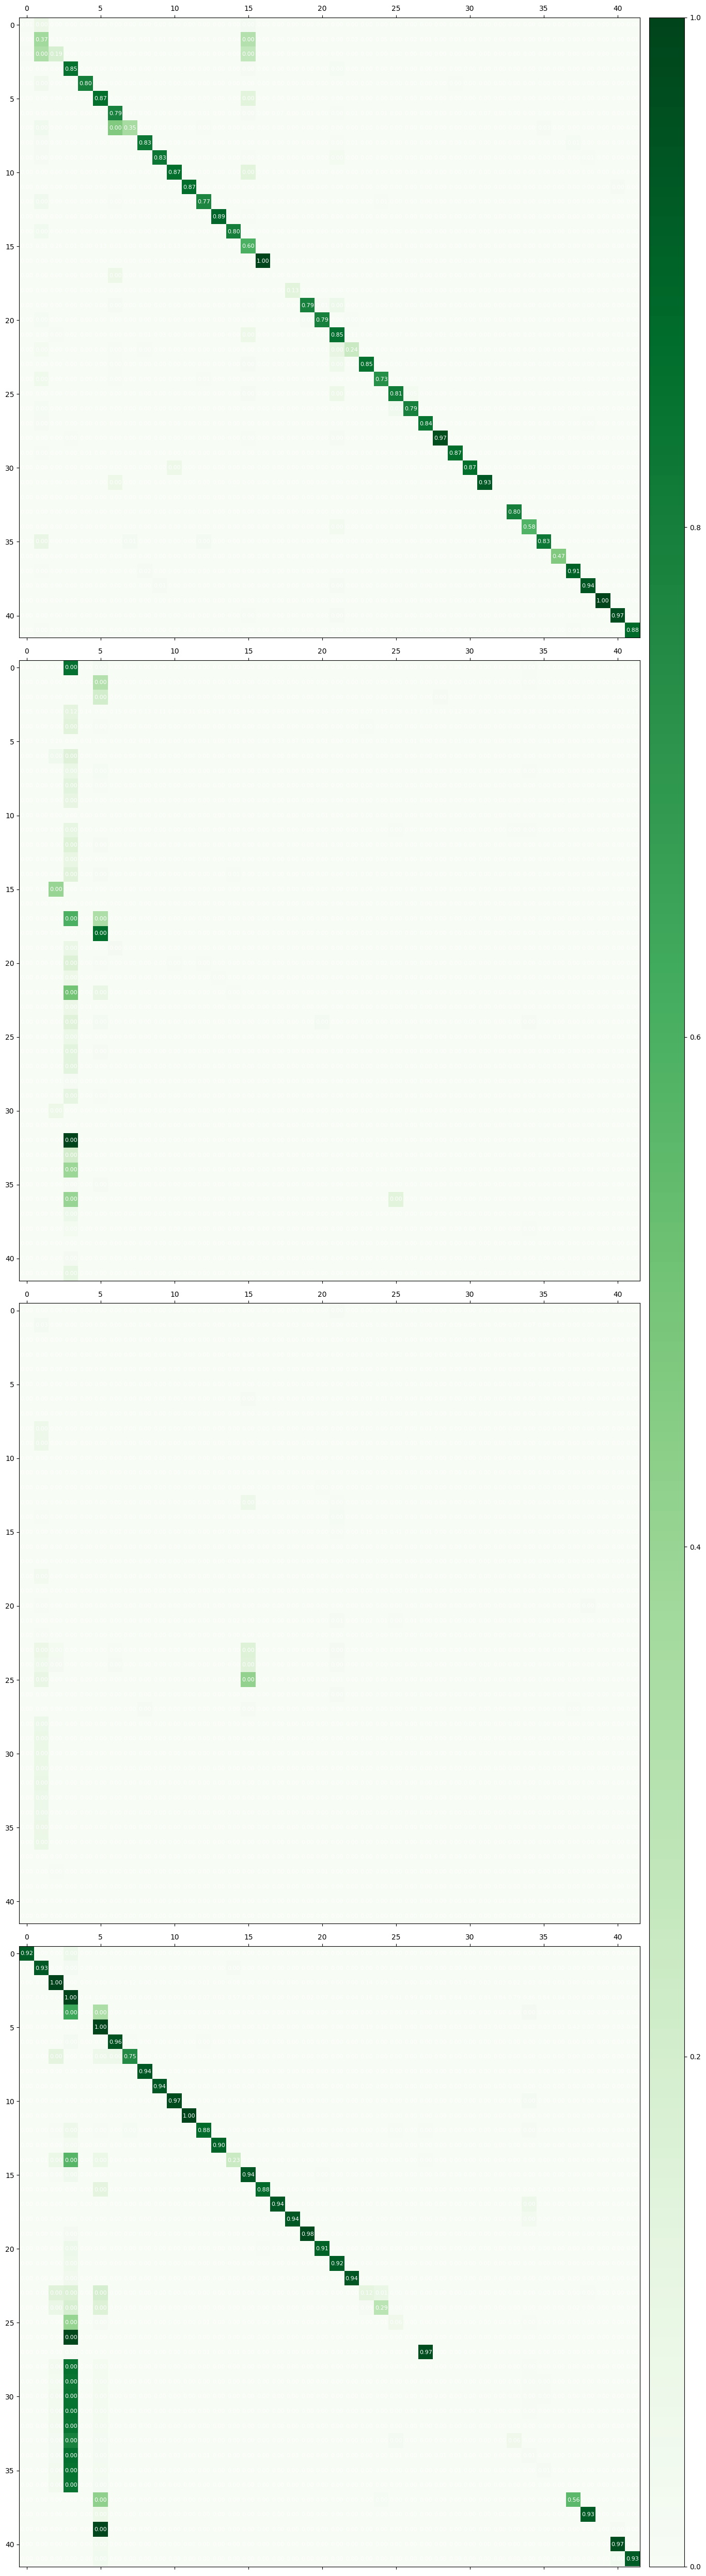

In [13]:
fig, axs = plt.subplots(4, 2, figsize=(14, 50), width_ratios=[19, 1])

gs = axs[0, 1].get_gridspec()
for ax in axs[:, 1]:
    ax.remove()
colorbar_ax = fig.add_subplot(gs[:, 1])

cm_mid = len(cm) // 2
img = axs[0, 0].matshow(cm[:cm_mid, :cm_mid], cmap="Greens", vmin=0, vmax=1)
axs[1, 0].matshow(cm[:cm_mid, cm_mid:], cmap="Greens", vmin=0, vmax=1)
axs[2, 0].matshow(cm[cm_mid:, :cm_mid], cmap="Greens", vmin=0, vmax=1)
axs[3, 0].matshow(cm[cm_mid:, cm_mid:], cmap="Greens", vmin=0, vmax=1)
plt.colorbar(img, cax=colorbar_ax)

for i in range(len(cm)):
    in_first_half = i < cm_mid
    i_mod = i % cm_mid
    for j in range(len(cm)):
        if in_first_half:
            if j < cm_mid:
                ax = axs[0, 0]
            else:
                ax = axs[1, 0]
        else:
            if j < cm_mid:
                ax = axs[2, 0]
            else:
                ax = axs[3, 0]
        val = f"{cm[i, j]:4.2f}"
        ax.text(
            i_mod,
            j % cm_mid,
            val,
            ha="center", va="center",
            color="white", fontsize=8,
        )

plt.tight_layout()
plt.savefig(results_dir / "confusion_matrix.png", dpi=300)
plt.show()

# ROC curves

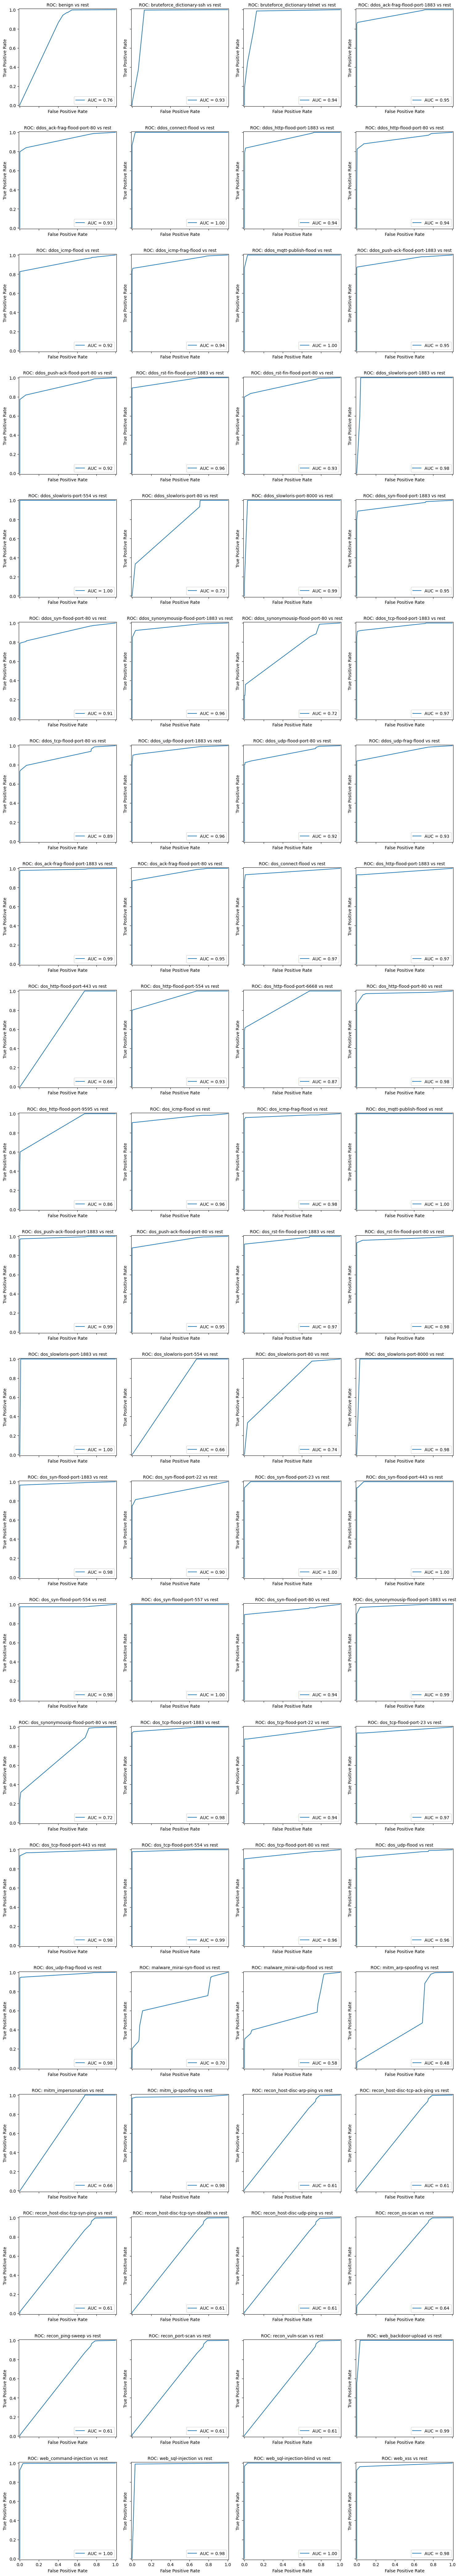

In [14]:
ncols = 4
nrows = ceil(len(trained_model.classes_) / ncols)

fig, axs = plt.subplots(nrows, ncols, figsize=(15, nrows*4), sharex=True, sharey=True)
axs = axs.flatten()

for i, cls_label in enumerate(trained_model.classes_):
    cls_y_true = y_test == cls_label
    cls_y_proba = y_proba[:, i]
    fpr, tpr, _ = roc_curve(cls_y_true, cls_y_proba)
    roc_auc = auc(fpr, tpr)
    disp = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
    disp.plot(ax=axs[i])
    axs[i].set_title(f"ROC: {cls_label} vs rest", fontsize=10)

plt.tight_layout()
plt.savefig(results_dir / "roc_curves.png", dpi=300)
plt.show()

# Precision-recall curves

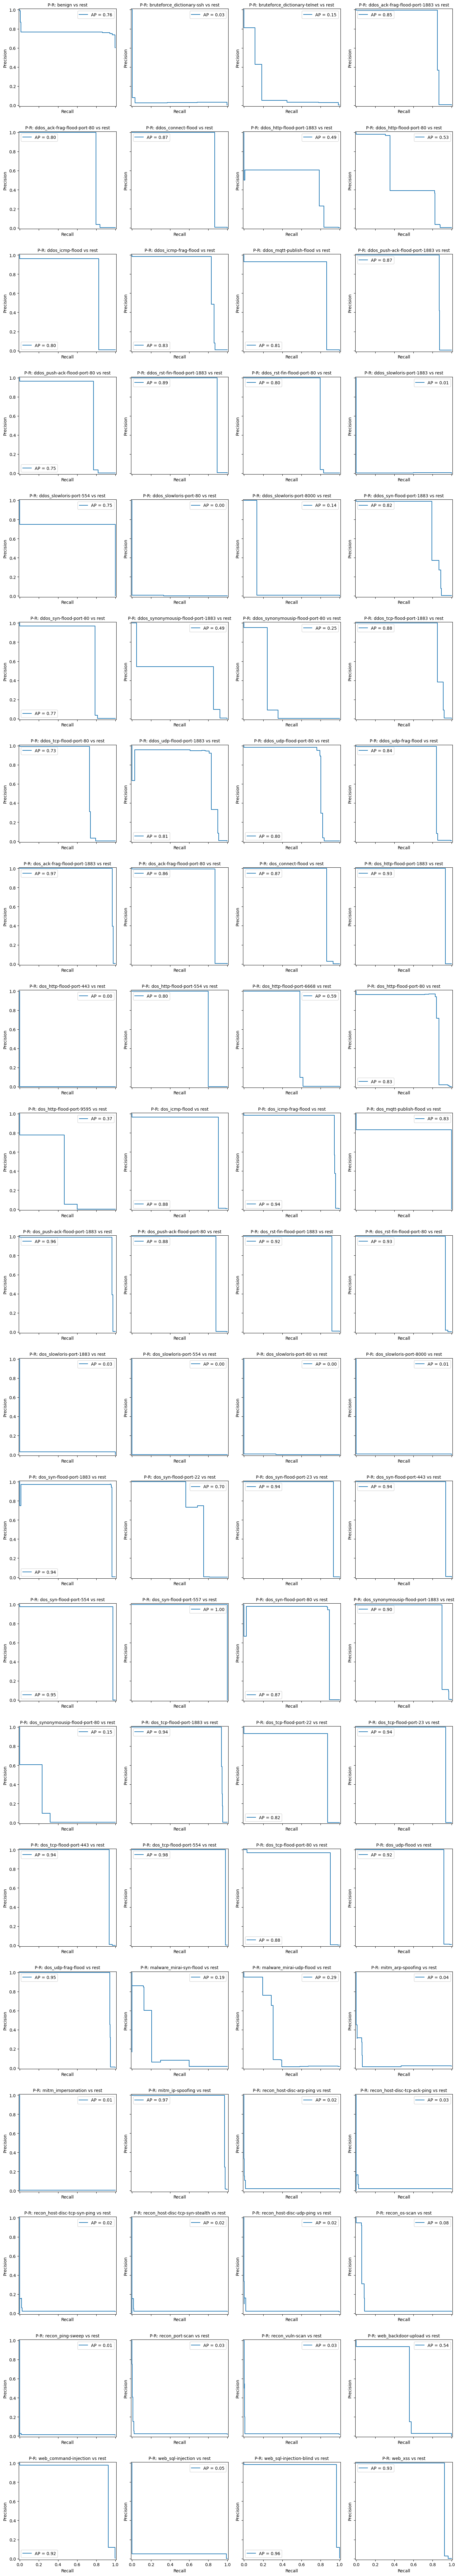

In [15]:
ncols = 4
nrows = ceil(len(trained_model.classes_) / ncols)

fig, axs = plt.subplots(nrows, ncols, figsize=(15, nrows*4), sharex=True, sharey=True)
axs = axs.flatten()

for i, cls_label in enumerate(trained_model.classes_):
    cls_y_true = y_test == cls_label
    cls_y_proba = y_proba[:, i]
    precision, recall, _ = precision_recall_curve(cls_y_true, cls_y_proba)
    ap = average_precision_score(cls_y_true, cls_y_proba)
    disp = PrecisionRecallDisplay(precision=precision, recall=recall)
    disp.plot(ax=axs[i], label=f"AP = {ap:.2f}")
    axs[i].legend(loc="best")
    axs[i].set_title(f"P-R: {cls_label} vs rest", fontsize=10)

plt.tight_layout()
plt.savefig(results_dir / "precision_recall_curves.png", dpi=300)
plt.show()